### If downloading CelebA from `torchvision` fails





In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/img_align_celeba.zip /content/
!unzip img_align_celeba.zip -d /content/celeba

### CelebA Attribute Dataset and DataLoader

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import random
import numpy as np


SEED = 1
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.cuda.manual_seed(SEED)

class CustomCelebADataset(Dataset):
    def __init__(self, data_dir, annotation_file, transform=None):
        self.data_dir = data_dir
        self.annotation_file = annotation_file
        self.transform = transform

        self.attribute_labels = self._read_attribute_labels()

    def __len__(self):
        return len(self.attribute_labels)

    def __getitem__(self, idx):
        image_filename, attribute_labels = self.attribute_labels[idx]
        image_path = os.path.join(self.data_dir, image_filename)
        image = Image.open(image_path)

        if self.transform:
            image = self.transform(image)

        attribute_labels = torch.FloatTensor(attribute_labels)

        return image, attribute_labels

    def _read_attribute_labels(self):
        with open(self.annotation_file, 'r') as file:
            lines = file.readlines()
            lines = lines[2:]  # Skip the header lines
            A_labels = []

            for line in lines:
                tokens = line.strip().split()
                image_filename = tokens[0]
                attribute_labels = [int(x) for x in tokens[1:]]
                attribute_labels = [(x + 1) // 2 for x in attribute_labels]
                attribute_labels = [float(x) for x in attribute_labels]
                attribute_labels = (image_filename, attribute_labels)
                A_labels.append(attribute_labels)

        return A_labels


# Define the path to your data directory and annotation file
data_dir = '/content/celeba/img_align_celeba'
annotation_file = '/content/list_attr_celeba.txt'

image_dim=64

# Define a transform for image preprocessing (optional)
transform = transforms.Compose([
    transforms.Resize((image_dim,image_dim)),
    transforms.ToTensor(),
])

# Create the custom CelebA dataset
celeba_dataset = CustomCelebADataset(data_dir=data_dir, annotation_file=annotation_file, transform=transform)

# Create a DataLoader for batch processing
batch_size = 64
data_loader = DataLoader(celeba_dataset, batch_size=batch_size, shuffle=True)

### Balanced Binary CelebA Dataset for Attribute Classification


In [ ]:
from tqdm import tqdm
from numpy.linalg import norm


def celeba_subset(dataset, feature_idx, num_samples=-1):

    NUM_CLASSES = 2
    labelset = {}
    for i in range(NUM_CLASSES):
        one_hot = torch.zeros(NUM_CLASSES)
        one_hot[i] = 1
        labelset[i] = one_hot

    by_class = {}
    # features = []
    if 1 not in by_class:
      by_class[1] = []
    for idx in tqdm(range(len(celeba_dataset))):
        ex, label =celeba_dataset[idx]
        # features.append(label[feature_idx])
        g = label[feature_idx].numpy().item()
        #ex = torch.mean(ex, dim=0)
        ex = ex.flatten()
        ex = ex / norm(ex)
        if g in by_class:
            if g==1:
              by_class[g].append((ex, labelset[g]))
            if g==0 and len(by_class[g])<len(by_class[1]):
              by_class[g].append((ex, labelset[g]))
            # by_class[g].append((ex, labelset[g]))
        else:
            by_class[g] = [(ex, labelset[g])]
        if len(by_class[1]) > 6000:
            break
    data = []
    if 1 in by_class:
        max_len = min(6000, len(by_class[1]))
        data.extend(by_class[1][:max_len])
        data.extend(by_class[0][:max_len])
    else:
        max_len = 1
        data.extend(by_class[0][:max_len])
    return data

sub_celeba_dataset=celeba_subset(celeba_dataset,15,len(celeba_dataset)) ## Glass
# sub_celeba_dataset=celeba_subset(celeba_dataset,31,len(celeba_dataset)) ## Smiling
# sub_celeba_dataset=celeba_subset(celeba_dataset,35,len(celeba_dataset)) ## Hat
# sub_celeba_dataset=celeba_subset(celeba_dataset,1,len(celeba_dataset)) ## Arched_Eyebrows

 11%|█         | 22568/202599 [00:23<03:08, 957.06it/s]


### Train a Fully Connected Neural Network on the Balanced CelebA Subset

In [ ]:
import torch
import torch.nn as nn
from torch.autograd import Variable, Function
import torch.optim as optim
from torchvision import models
from torch.nn.functional import upsample
from copy import deepcopy
import torch.nn.functional as F


class Nonlinearity(torch.nn.Module):
    def __init__(self):
        super(Nonlinearity, self).__init__()

    def forward(self, x):
        return F.relu(x)


class Net(nn.Module):

    def __init__(self, dim, num_classes=2, num_layers=4):
        super(Net, self).__init__()
        bias = True
        k = 1024
        self.dim = dim
        self.width = k
        self.first = nn.Linear(dim, k, bias=bias)
        layers = []
        for _ in range(num_layers - 1):
            layers.append(Nonlinearity())
            layers.append(nn.Linear(k, k, bias=bias))

        layers.append(Nonlinearity())
        layers.append(nn.Linear(k, num_classes, bias=bias))

        self.fc = nn.Sequential(*layers)

    def forward(self, x):
        return self.fc(self.first(x))

data_loader = DataLoader(sub_celeba_dataset, batch_size=batch_size, shuffle=True)

NN=Net(dim=3*image_dim*image_dim).cuda()

loss_function = nn.MSELoss()
optimizer = torch.optim.SGD(NN.parameters(), lr=0.1,momentum=0.9)

num_epochs=100

# Training loop
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(data_loader):
        # Move data to GPU
        images, labels = images.cuda(), labels.cuda()

        # Forward pass
        outputs = NN(images)
        loss = loss_function(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print loss
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(data_loader)}], Loss: {loss.item():.4f}')

print("Training complete")

Epoch [1/100], Step [100/188], Loss: 0.2602
Epoch [2/100], Step [100/188], Loss: 0.2618
Epoch [3/100], Step [100/188], Loss: 0.2519
Epoch [4/100], Step [100/188], Loss: 0.2386
Epoch [5/100], Step [100/188], Loss: 0.2502
Epoch [6/100], Step [100/188], Loss: 0.2529
Epoch [7/100], Step [100/188], Loss: 0.2479
Epoch [8/100], Step [100/188], Loss: 0.2493
Epoch [9/100], Step [100/188], Loss: 0.2541
Epoch [10/100], Step [100/188], Loss: 0.2498
Epoch [11/100], Step [100/188], Loss: 0.2522
Epoch [12/100], Step [100/188], Loss: 0.2491
Epoch [13/100], Step [100/188], Loss: 0.2494
Epoch [14/100], Step [100/188], Loss: 0.2511
Epoch [15/100], Step [100/188], Loss: 0.2492
Epoch [16/100], Step [100/188], Loss: 0.2500
Epoch [17/100], Step [100/188], Loss: 0.2542
Epoch [18/100], Step [100/188], Loss: 0.2549
Epoch [19/100], Step [100/188], Loss: 0.2492
Epoch [20/100], Step [100/188], Loss: 0.2540
Epoch [21/100], Step [100/188], Loss: 0.2466
Epoch [22/100], Step [100/188], Loss: 0.2405
Epoch [23/100], Ste

### Visualize the Top Eigenvector of the First-Layer Feature Matrix

(3, 64, 64)


array([[[0.65028846, 0.64307535, 0.62678957],
        [0.63477314, 0.6299786 , 0.6166445 ],
        [0.6060098 , 0.60199463, 0.59253925],
        ...,
        [0.60031277, 0.60699207, 0.6038343 ],
        [0.5985943 , 0.60465544, 0.5998706 ],
        [0.59597445, 0.60268897, 0.5884326 ]],

       [[0.6230248 , 0.61672103, 0.609837  ],
        [0.60303247, 0.5977411 , 0.58909166],
        [0.58691245, 0.57675153, 0.5731442 ],
        ...,
        [0.59987485, 0.6045517 , 0.59454334],
        [0.5975774 , 0.6059873 , 0.59460855],
        [0.602659  , 0.61205065, 0.59831375]],

       [[0.59589493, 0.58727896, 0.5908069 ],
        [0.580519  , 0.57469666, 0.57778335],
        [0.56629986, 0.55521816, 0.5597895 ],
        ...,
        [0.59016865, 0.59227115, 0.5803077 ],
        [0.58921444, 0.5931022 , 0.582358  ],
        [0.598038  , 0.6087191 , 0.5969833 ]],

       ...,

       [[0.60593164, 0.59186804, 0.5856887 ],
        [0.58768135, 0.5742399 , 0.56487155],
        [0.5671895 , 0

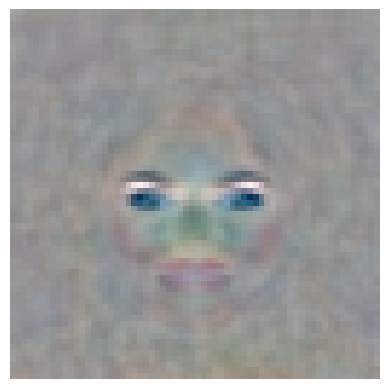

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
def visualize_M(M, idx):
    d, _ = M.shape
    SIZE = int(np.sqrt(d // 3))
    F1 = np.diag(M[:SIZE**2, :SIZE**2]).reshape(SIZE, SIZE)
    F2 = np.diag(M[SIZE**2:2*SIZE**2, SIZE**2:2*SIZE**2]).reshape(SIZE, SIZE)
    F3 = np.diag(M[2*SIZE**2:, 2*SIZE**2:]).reshape(SIZE, SIZE)
    F = np.stack([F1, F2, F3])
    print(F.shape)
    F = (F - F.min()) / (F.max() - F.min())
    F = np.rollaxis(F, 0, 3)
    plt.imshow(F)
    plt.axis('off')
    return F

def visualize_top_M(M, idx):
    d= M.shape[0]
    SIZE = int(np.sqrt(d // 3))
    F1 = M[:SIZE**2].reshape(SIZE, SIZE)
    F2 = M[SIZE**2:2*SIZE**2].reshape(SIZE, SIZE)
    F3 = M[2*SIZE**2:].reshape(SIZE, SIZE)
    F = np.stack([F1, F2, F3])
    print(F.shape)
    F = (F - F.min()) / (F.max() - F.min())
    F = np.rollaxis(F, 0, 3)
    plt.imshow(F)
    plt.axis('off')
    return F

M = NN.first.weight.data.detach().cpu().numpy()
M = M.T @ M
# visualize_M(M, 0)


eigenvalues, eigenvectors = np.linalg.eigh(M)
top_eigenvector = eigenvectors[:, -1]  # The eigenvectors are in ascending order

visualize_top_M(top_eigenvector,0)
